# 🛰️ AFETSONAR — Notebook 1: Kurulum ve Veri Hazırlığı

**Calamitas AI · Teknofest 2025 · Plan v2.0**

---

## 📌 Bu Notebook Ne Yapıyor?

Bu, AFETSONAR projesinin **ilk adımı**. Burada şunları yapacağız:

1. **Google Drive'a bağlanmak** — modellerimiz ve verilerimiz kaybolmasın
2. **GPU'yu kontrol etmek** — A100 var mı, bf16 destekliyor mu?
3. **Proje klasör yapısını kurmak** — düzenli bir AFETSONAR/ klasörü
4. **xView2 veri setini indirmek** — Kaggle'dan, Drive'a kaydederek (bir kere indir, hep kullan)
5. **Maskeleri üretmek** — JSON poligon etiketlerini PNG mask'lara çevirmek
6. **Dosya indeksini çıkarmak** — bütün pre/post/mask eşleşmelerini önceden hesaplamak (eğitim hızını 100x artırır)
7. **Stratified split yapmak** — train/val/test'i afet türüne göre dengeli bölmek
8. **`src/` modüllerini yazmak** — `XBDDataset`, augmentation pipeline, yardımcı fonksiyonlar
9. **Sanity check** — "Acaba gerçekten çalışıyor mu?" testi

## ⚙️ Çalıştırmadan Önce

1. **Runtime → Change runtime type → A100 GPU** seçtiğinden emin ol
2. Hücreleri **sırayla** çalıştır, atlama
3. Bir hücrede hata alırsan dur, mesajı bana gönder

---

## 1️⃣ Google Drive Bağlantısı ve GPU Kontrolü

### Bu hücre ne yapıyor?

**A) Drive bağlantısı:** Colab oturumu kapanınca dosyaların gider. Drive'a bağlanırsak yazdığımız her şey **kalıcı** olur. Bu yüzden her notebook'un ilk hücresi Drive mount olacak.

**B) GPU kontrolü:** Colab her zaman aynı GPU'yu vermez. Bu hücre A100/L4/T4 hangisini aldığını otomatik tespit edip ona göre `batch_size` öneriyor.

### Beklenen çıktı

```
✅ Drive bağlandı
✅ GPU: NVIDIA A100-SXM4-40GB
   VRAM: 40.0 GB
   bf16 desteği: ✅
   Önerilen batch_size: 16
```

### Hata olursa
- "GPU YOK" → Runtime → Change runtime type → A100 GPU seç → Restart runtime
- "Drive mount failed" → Tarayıcı popup'ından Google'a izin ver

In [1]:
# === 1. Drive Mount ===
from google.colab import drive
import os

print("🔄 Google Drive bağlanıyor...")
drive.mount('/content/drive', force_remount=True)

PROJECT_ROOT = "/content/drive/MyDrive/AFETSONAR"
os.makedirs(PROJECT_ROOT, exist_ok=True)
print(f"✅ Proje klasörü: {PROJECT_ROOT}")

# === 2. GPU Kontrolü ===
import torch

print("\n⚙️  Donanım Kontrolü")
print("=" * 50)

if not torch.cuda.is_available():
    print("❌ GPU YOK!")
    print("   Runtime → Change runtime type → A100 GPU seç")
    raise RuntimeError("GPU bulunamadı")

gpu_name = torch.cuda.get_device_name(0)
vram_gb = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1)
bf16_supported = torch.cuda.is_bf16_supported()

print(f"✅ GPU: {gpu_name}")
print(f"   VRAM: {vram_gb} GB")
print(f"   CUDA: {torch.version.cuda}")
print(f"   PyTorch: {torch.__version__}")
print(f"   bf16 desteği: {'✅' if bf16_supported else '❌'}")

if "A100" in gpu_name:
    RECOMMENDED_BATCH = 16
    PRECISION = "bf16"
elif "L4" in gpu_name or "V100" in gpu_name:
    RECOMMENDED_BATCH = 8
    PRECISION = "bf16" if bf16_supported else "fp16"
elif "T4" in gpu_name:
    RECOMMENDED_BATCH = 4
    PRECISION = "fp16"
else:
    RECOMMENDED_BATCH = 8
    PRECISION = "fp16"

print(f"\n📊 Bu donanım için öneriler:")
print(f"   batch_size = {RECOMMENDED_BATCH}")
print(f"   precision  = {PRECISION}")

%store RECOMMENDED_BATCH
%store PRECISION
%store PROJECT_ROOT

🔄 Google Drive bağlanıyor...
Mounted at /content/drive
✅ Proje klasörü: /content/drive/MyDrive/AFETSONAR

⚙️  Donanım Kontrolü
✅ GPU: NVIDIA H100 80GB HBM3
   VRAM: 79.2 GB
   CUDA: 12.8
   PyTorch: 2.10.0+cu128
   bf16 desteği: ✅

📊 Bu donanım için öneriler:
   batch_size = 8
   precision  = fp16
Stored 'RECOMMENDED_BATCH' (int)
Stored 'PRECISION' (str)
Stored 'PROJECT_ROOT' (str)


## 2️⃣ Proje Klasör Yapısını Kurma

### Bu hücre ne yapıyor?

AFETSONAR/ altında 12 alt klasör oluşturuyor. Her şey yerli yerinde olsun istiyoruz.

| Klasör | Ne için? |
|---|---|
| `data/raw/xview2/` | Kaggle'dan inen ham xBD (sadece okuma) |
| `data/processed/masks/` | JSON'dan üretilmiş PNG maskeler |
| `data/splits/` | train.csv, val.csv, test.csv |
| `src/` | Tekrar kullanılan Python modülleri |
| `checkpoints/teacher/` | Öğretmen model ağırlıkları |
| `checkpoints/student/` | Öğrenci model ağırlıkları |
| `logs/` | Eğitim grafikleri |
| `outputs/maps/` | Folium HTML haritaları |
| `outputs/reports/` | Metrik raporları |

In [3]:
import os

SUBDIRS = [
    "data/raw/xview2",
    "data/processed/masks",
    "data/splits",
    "src",
    "notebooks",
    "checkpoints/teacher",
    "checkpoints/student",
    "logs/teacher",
    "logs/student",
    "outputs/maps",
    "outputs/reports",
    "outputs/visualizations",
]

print("📁 Klasör yapısı kuruluyor...")
print("=" * 50)
for sub in SUBDIRS:
    full_path = os.path.join(PROJECT_ROOT, sub)
    os.makedirs(full_path, exist_ok=True)
    print(f"  ✅ {sub}")

DATA_RAW = os.path.join(PROJECT_ROOT, "data/raw/xview2")
DATA_MASKS = os.path.join(PROJECT_ROOT, "data/processed/masks")
DATA_SPLITS = os.path.join(PROJECT_ROOT, "data/splits")
SRC_DIR = os.path.join(PROJECT_ROOT, "src")
CKPT_TEACHER = os.path.join(PROJECT_ROOT, "checkpoints/teacher")
CKPT_STUDENT = os.path.join(PROJECT_ROOT, "checkpoints/student")

%store DATA_RAW
%store DATA_MASKS
%store DATA_SPLITS
%store SRC_DIR
%store CKPT_TEACHER
%store CKPT_STUDENT

print(f"\n✅ {len(SUBDIRS)} klasör hazır")

📁 Klasör yapısı kuruluyor...
  ✅ data/raw/xview2
  ✅ data/processed/masks
  ✅ data/splits
  ✅ src
  ✅ notebooks
  ✅ checkpoints/teacher
  ✅ checkpoints/student
  ✅ logs/teacher
  ✅ logs/student
  ✅ outputs/maps
  ✅ outputs/reports
  ✅ outputs/visualizations
Stored 'DATA_RAW' (str)
Stored 'DATA_MASKS' (str)
Stored 'DATA_SPLITS' (str)
Stored 'SRC_DIR' (str)
Stored 'CKPT_TEACHER' (str)
Stored 'CKPT_STUDENT' (str)

✅ 12 klasör hazır


## 3️⃣ Kütüphane Kurulumu

### Bu hücre ne yapıyor?

AFETSONAR'ın ihtiyacı olan tüm Python paketlerini **akıllıca** kuruyor.

### ⚠️ Önemli: Strateji değişti

İlk versiyonda sürüm pinleme yapıyorduk (`albumentations==1.4.18` gibi). Ama bu Colab'ın güncel ortamıyla (numpy 2.x, opencv) **çakışıyor**. Aldığın hata bunun kanıtı:

```
ImportError: cannot import name 'geometric' from partially initialized module
ImportError: cannot import name 'MAX_VALUES_BY_DTYPE'
```

Bu yüzden yaklaşımı değiştirdik:

1. **Önce bak**: Colab'da zaten kurulu mu?
2. **Varsa dokunma**: Sürüm çakışması yaratma
3. **Yoksa kur**: Geniş sürüm aralığıyla (`>=1.3.0,<2.0.0` gibi)
4. **Sonunda test et**: Her kütüphaneyi gerçekten import et, çalışıyor mu kontrol et

Bu yaklaşım daha **dayanıklı**: Colab ortamı güncellense bile çalışmaya devam eder.

### Kütüphane grupları

**ML Çekirdek:** transformers, segmentation-models-pytorch, albumentations, accelerate
**Coğrafi & Harita:** osmnx, rasterio, shapely, folium, exifread, geopy
**Yardımcı:** kaggle

### Beklenen çıktı

```
[Mevcut durum]
  ✅ transformers        4.44.2  (zaten kurulu)
  ✅ albumentations      1.4.x   (zaten kurulu)
  ⏳ osmnx               kurulacak
  ...

[Eksik olanlar kuruluyor]
  → osmnx kuruluyor...

[Import testi]
  ✅ transformers (SegformerForSemanticSegmentation)
  ✅ albumentations + ToTensorV2
  ...

✅ Tüm kütüphaneler hazır ve çalışıyor
```

### Hata olursa

Sondaki import testinde ❌ varsa:
1. **Runtime → Restart runtime** (ÇOK önemli — pip install sonrası genelde restart gerekir)
2. Sonra hücreyi tekrar çalıştır
3. Hala hata alıyorsan tam hata mesajını bana gönder

In [4]:
# === Colab-uyumlu kütüphane kurulumu ===
# Strateji: Colab'da zaten kurulu olanları DOKUNMA (sürüm çakışması yaratır),
# sadece eksik olanları kur. albumentations ve transformers için sürüm pinlemeyi
# kaldırdık çünkü Colab'ın numpy 2.x / opencv ile çakışıyordu.

import sys
print("📦 Kütüphane durumu kontrol ediliyor...")
print("=" * 50)

# === 1. Mevcut sürümleri kontrol et ===
def check_lib(name, import_name=None):
    import_name = import_name or name
    try:
        mod = __import__(import_name)
        ver = getattr(mod, '__version__', 'unknown')
        print(f"  ✅ {name:30s} {ver}  (zaten kurulu)")
        return True
    except ImportError:
        print(f"  ⏳ {name:30s} kurulacak")
        return False

print("\n[Mevcut durum]")
have_transformers = check_lib("transformers")
have_smp = check_lib("segmentation-models-pytorch", "segmentation_models_pytorch")
have_albu = check_lib("albumentations")
have_accelerate = check_lib("accelerate")
have_rasterio = check_lib("rasterio")
have_osmnx = check_lib("osmnx")
have_folium = check_lib("folium")
have_shapely = check_lib("shapely")
have_exifread = check_lib("exifread")
have_geopy = check_lib("geopy")
have_kaggle = check_lib("kaggle")

# === 2. Eksik olanları kur (Colab ortamına saygılı şekilde) ===
print("\n[Eksik olanlar kuruluyor]")

# Colab'da albumentations zaten gelir, ama gelmezse kur
if not have_albu:
    print("  → albumentations kuruluyor (Colab uyumlu sürüm)...")
    !pip install -q "albumentations>=1.3.0,<2.0.0"

# transformers Colab'da var ama eski olabilir, sadece çok eskiyse güncelle
if not have_transformers:
    print("  → transformers kuruluyor...")
    !pip install -q "transformers>=4.40.0"

if not have_smp:
    print("  → segmentation-models-pytorch kuruluyor...")
    !pip install -q segmentation-models-pytorch

if not have_accelerate:
    print("  → accelerate kuruluyor...")
    !pip install -q accelerate

# Coğrafi kütüphaneler — Colab'da rasterio/shapely/folium genelde gelir
if not have_rasterio:
    print("  → rasterio kuruluyor...")
    !pip install -q rasterio

if not have_osmnx:
    print("  → osmnx kuruluyor...")
    !pip install -q osmnx

if not have_folium:
    print("  → folium kuruluyor...")
    !pip install -q folium

if not have_shapely:
    print("  → shapely kuruluyor...")
    !pip install -q shapely

if not have_exifread:
    print("  → exifread kuruluyor...")
    !pip install -q exifread

if not have_geopy:
    print("  → geopy kuruluyor...")
    !pip install -q geopy

if not have_kaggle:
    print("  → kaggle kuruluyor...")
    !pip install -q kaggle

# === 3. Import testi (gerçekten çalışıyorlar mı?) ===
print("\n[Import testi]")
print("=" * 50)

import_errors = []

def test_import(label, code_str):
    try:
        exec(code_str, globals())
        print(f"  ✅ {label}")
    except Exception as e:
        print(f"  ❌ {label}")
        print(f"     {type(e).__name__}: {e}")
        import_errors.append((label, str(e)))

test_import("transformers (SegformerForSemanticSegmentation)",
            "from transformers import SegformerForSemanticSegmentation")
test_import("segmentation_models_pytorch",
            "import segmentation_models_pytorch as smp")
test_import("albumentations + ToTensorV2",
            "import albumentations as A; from albumentations.pytorch import ToTensorV2")
test_import("accelerate",
            "from accelerate import Accelerator")
test_import("rasterio",
            "import rasterio")
test_import("osmnx",
            "import osmnx as ox")
test_import("folium",
            "import folium")
test_import("shapely",
            "from shapely.geometry import Polygon")
test_import("exifread",
            "import exifread")
test_import("geopy",
            "from geopy.distance import geodesic")

if import_errors:
    print("\n⚠️  HATA ÖZETİ:")
    for label, err in import_errors:
        print(f"   • {label}: {err}")
    print("\n💡 Çözüm önerisi: Runtime → Restart runtime → bu hücreyi tekrar çalıştır")
    print("   Eğer hala hata alıyorsan, hata mesajını bana gönder.")
else:
    print("\n✅ Tüm kütüphaneler hazır ve çalışıyor")

📦 Kütüphane durumu kontrol ediliyor...

[Mevcut durum]
  ✅ transformers                   5.0.0  (zaten kurulu)
  ⏳ segmentation-models-pytorch    kurulacak
  ✅ albumentations                 2.0.8  (zaten kurulu)
  ✅ accelerate                     1.13.0  (zaten kurulu)
  ✅ rasterio                       1.5.0  (zaten kurulu)
  ⏳ osmnx                          kurulacak
  ✅ folium                         0.20.0  (zaten kurulu)
  ✅ shapely                        2.1.2  (zaten kurulu)
  ⏳ exifread                       kurulacak
  ✅ geopy                          2.4.1  (zaten kurulu)
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


NameError: name 'exit' is not defined

## 4️⃣ xView2 Veri Setini İndirme

### Bu hücre ne yapıyor?

xBD veri setini Kaggle'dan indiriyor ve **Drive'a** kaydediyor. Mantık: **bir kere indir, bin kere kullan.**

İki senaryo:
1. **Drive'da zaten varsa:** atla
2. **Yoksa:** Kaggle API → indir → unzip → Drive'a taşı

### Neden Drive'a kaydediyoruz?

Colab'ın local diski `/content/` her oturum kapanışta **silinir**. 30 GB veriyi her oturumda yeniden indirmek istemezsin.

### kaggle.json hakkında

1. https://www.kaggle.com/settings adresine git
2. API bölümünde "Create New Token" tıkla
3. `kaggle.json` inecek
4. Bu hücre çalıştığında "dosya seç" diyecek, o dosyayı seç

**Ayrıca dataset sayfasına bir kez git ve "I Understand and Accept" tıkla:**
https://www.kaggle.com/datasets/tunguz/xview2-challenge-dataset-train-and-test

### Hata olursa
- "kaggle.json bulunamadı" → yeniden çalıştır, dosyayı yükle
- "403 Forbidden" → Kaggle dataset sayfasında accept tıkla
- Disk dolu → Drive'da yer aç (~30 GB)

In [5]:
import os
import shutil

has_data = False
if os.path.exists(DATA_RAW):
    contents = os.listdir(DATA_RAW)
    if len(contents) > 0:
        expected_dirs = ['train', 'test', 'hold', 'tier3']
        found_dirs = [d for d in contents if d.lower() in expected_dirs]
        if len(found_dirs) > 0:
            has_data = True
            print(f"✅ Drive'da xBD verisi zaten var: {found_dirs}")
            print(f"   ⏭️  İndirme atlanıyor")

if not has_data:
    print("📥 Drive'da xBD verisi yok, Kaggle'dan indirilecek")
    print("=" * 50)

    from google.colab import files
    print("\n🔑 Lütfen kaggle.json dosyasını seç:")
    uploaded = files.upload()

    kaggle_filename = next(iter(uploaded))
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    shutil.copy(kaggle_filename, os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    print(f"✅ Kaggle anahtarı yerleştirildi")

    print("\n⬇️  xView2 indiriliyor (10-15 dk)...")
    LOCAL_DOWNLOAD = "/content/xview2_download"
    os.makedirs(LOCAL_DOWNLOAD, exist_ok=True)

    !kaggle datasets download -d tunguz/xview2-challenge-dataset-train-and-test -p {LOCAL_DOWNLOAD}

    print("\n📦 Zip açılıyor (5-10 dk)...")
    !unzip -q {LOCAL_DOWNLOAD}/xview2-challenge-dataset-train-and-test.zip -d /content/xview2_extracted

    print("\n📤 Drive'a taşınıyor...")
    !rsync -ah --info=progress2 /content/xview2_extracted/ {DATA_RAW}/

    shutil.rmtree(LOCAL_DOWNLOAD, ignore_errors=True)
    shutil.rmtree("/content/xview2_extracted", ignore_errors=True)

    print(f"\n✅ xView2 verisi Drive'a kaydedildi")

print("\n📊 Veri seti envanteri:")
print("=" * 50)
for root, dirs, files_list in os.walk(DATA_RAW):
    depth = root.replace(DATA_RAW, '').count(os.sep)
    if depth <= 2:
        indent = '  ' * depth
        print(f"{indent}{os.path.basename(root)}/  ({len(files_list)} dosya, {len(dirs)} klasör)")

📥 Drive'da xBD verisi yok, Kaggle'dan indirilecek

🔑 Lütfen kaggle.json dosyasını seç:


Saving kaggle.json to kaggle.json
✅ Kaggle anahtarı yerleştirildi

⬇️  xView2 indiriliyor (10-15 dk)...
Dataset URL: https://www.kaggle.com/datasets/tunguz/xview2-challenge-dataset-train-and-test
License(s): CC-BY-NC-SA-4.0
100% 10.3G/10.3G [01:20<00:00, 138MB/s]


📦 Zip açılıyor (5-10 dk)...

📤 Drive'a taşınıyor...
         11.33G 100%   15.19MB/s    0:11:50 (xfr#13062, to-chk=0/13070)

✅ xView2 verisi Drive'a kaydedildi

📊 Veri seti envanteri:
xview2/  (0 dosya, 2 klasör)
  test/  (0 dosya, 1 klasör)
    test/  (0 dosya, 1 klasör)
  train/  (0 dosya, 1 klasör)
    train/  (0 dosya, 2 klasör)


## 5️⃣ Dosya İndeksi Çıkarma — KRİTİK ADIM ⚡

### Bu hücre ne yapıyor?

Bu hücre, **eski notebook'undaki en büyük performans hatasını** düzeltiyor.

Eski `DisasterDataset` her örnek için `os.walk()` yapıyordu:
```python
def __getitem__(self, i):
    for root, dirs, files in os.walk(self.raw_data_dir):  # ❌ Her batch'te tüm klasörü tara
        ...
```

10.000 görüntü için her epoch'ta **10.000 × tam disk taraması** = eğitim 100x yavaşlar.

### Doğru yaklaşım

Tüm dosya yollarını **bir kere** tarıyoruz, bir CSV'ye yazıyoruz, sonra her `__getitem__` sadece CSV satırını okuyor. **O(n) → O(1).**

### Disaster type çıkarma

xBD dosya isimlerinde afet türü gizli:
- `hurricane-harvey_*` → kasırga
- `palu-tsunami_*` → tsunami
- `socal-fire_*` → yangın
- `mexico-earthquake_*` → deprem
- `midwest-flooding_*` → sel

In [6]:
import os
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd

print("🔍 Dosya indeksi çıkarılıyor...")
print("=" * 50)

DISASTER_KEYWORDS = {
    'earthquake': 'deprem',
    'tsunami':    'tsunami',
    'fire':       'yangin',
    'wildfire':   'yangin',
    'volcano':    'yangin',
    'hurricane':  'kasirga',
    'tornado':    'kasirga',
    'typhoon':    'kasirga',
    'cyclone':    'kasirga',
    'flood':      'sel',
    'flooding':   'sel',
    'tide':       'sel',
}

DISASTER_CLASSES = ['deprem', 'sel', 'yangin', 'kasirga', 'tsunami']
DISASTER_TO_IDX = {name: i for i, name in enumerate(DISASTER_CLASSES)}

def extract_disaster_type(filename):
    name_lower = filename.lower()
    for keyword, disaster in DISASTER_KEYWORDS.items():
        if keyword in name_lower:
            return disaster
    return None

print("📂 Post-disaster görüntüleri taranıyor...")
post_files = list(Path(DATA_RAW).rglob("*_post_disaster.png"))
print(f"   {len(post_files)} adet bulundu")

if len(post_files) == 0:
    print("⚠️  HATA: Hiç post_disaster görüntüsü bulunamadı!")
    raise FileNotFoundError("xBD verisi bulunamadı")

records = []
missing_pre = 0
missing_json = 0
unknown_disaster = 0

for post_path in tqdm(post_files, desc="İndeks oluşturuluyor"):
    post_path_str = str(post_path)
    filename = post_path.name

    pre_filename = filename.replace("_post_disaster", "_pre_disaster")
    pre_path = post_path.parent / pre_filename

    if not pre_path.exists():
        missing_pre += 1
        continue

    json_path_str = post_path_str.replace("/images/", "/labels/").replace(".png", ".json")
    if not os.path.exists(json_path_str):
        missing_json += 1
        continue

    disaster = extract_disaster_type(filename)
    if disaster is None:
        unknown_disaster += 1
        continue

    parts = post_path.parts
    xbd_split = None
    for p in parts:
        if p.lower() in ['train', 'test', 'hold', 'tier3']:
            xbd_split = p.lower()
            break

    mask_path = os.path.join(DATA_MASKS, filename)

    records.append({
        'post_path': post_path_str,
        'pre_path': str(pre_path),
        'json_path': json_path_str,
        'mask_path': mask_path,
        'disaster_type': disaster,
        'disaster_idx': DISASTER_TO_IDX[disaster],
        'xbd_split': xbd_split,
        'filename': filename,
    })

print(f"\n📊 İndeks özeti:")
print(f"   Toplam post bulundu:        {len(post_files)}")
print(f"   Eksik pre (atlandı):        {missing_pre}")
print(f"   Eksik JSON (atlandı):       {missing_json}")
print(f"   Tanınmayan disaster:        {unknown_disaster}")
print(f"   ✅ İndekse alındı:          {len(records)}")

df = pd.DataFrame(records)
index_path = os.path.join(DATA_SPLITS, "file_index.csv")
df.to_csv(index_path, index=False)
print(f"\n💾 İndeks kaydedildi: {index_path}")

print(f"\n🌪️  Afet türü dağılımı:")
disaster_counts = df['disaster_type'].value_counts()
for disaster, count in disaster_counts.items():
    pct = 100 * count / len(df)
    bar = '█' * int(pct / 2)
    print(f"   {disaster:10s} {count:5d}  ({pct:5.1f}%) {bar}")

print(f"\n📂 xBD orijinal split'leri:")
for split_name, count in df['xbd_split'].value_counts().items():
    print(f"   {str(split_name):10s} {count:5d}")

🔍 Dosya indeksi çıkarılıyor...
📂 Post-disaster görüntüleri taranıyor...
   2799 adet bulundu


İndeks oluşturuluyor:   0%|          | 0/2799 [00:00<?, ?it/s]


📊 İndeks özeti:
   Toplam post bulundu:        2799
   Eksik pre (atlandı):        0
   Eksik JSON (atlandı):       0
   Tanınmayan disaster:        0
   ✅ İndekse alındı:          2799

💾 İndeks kaydedildi: /content/drive/MyDrive/AFETSONAR/data/splits/file_index.csv

🌪️  Afet türü dağılımı:
   kasirga     1219  ( 43.6%) █████████████████████
   yangin      1067  ( 38.1%) ███████████████████
   sel          279  ( 10.0%) ████
   deprem       121  (  4.3%) ██
   tsunami      113  (  4.0%) ██

📂 xBD orijinal split'leri:
   train       2799


## 6️⃣ Stratified Train/Val/Test Split

### Bu hücre ne yapıyor?

Veriyi 3'e bölüyor: **%70 train, %15 val, %15 test**, ama random değil — **stratified**: her bölümde her afet türünden dengeli sayıda örnek.

### Neden stratified?

Random split olabilirdi şöyle:
- Train'de %90 kasırga, %10 deprem
- Val'de %50 deprem, %0 tsunami

Bu durumda model val'de iyi gözükür ama gerçek dünyada bok gibi olur. Stratified bunu engeller.

Plan v2 1.2: *"Train / Val / Test split: %70 / %15 / %15 — stratified by disaster_type"*

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(os.path.join(DATA_SPLITS, "file_index.csv"))
print(f"📂 İndeks yüklendi: {len(df)} kayıt")

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['disaster_type'], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['disaster_type'], random_state=42
)

print(f"\n📊 Split boyutları:")
print(f"   Train: {len(train_df):5d}  ({100*len(train_df)/len(df):.1f}%)")
print(f"   Val:   {len(val_df):5d}  ({100*len(val_df)/len(df):.1f}%)")
print(f"   Test:  {len(test_df):5d}  ({100*len(test_df)/len(df):.1f}%)")

print(f"\n🌪️  Her split'te disaster type dağılımı (%):")
print(f"{'Disaster':12s} {'Train':>8s} {'Val':>8s} {'Test':>8s}")
print("-" * 40)
for disaster in DISASTER_CLASSES:
    train_pct = 100 * (train_df['disaster_type'] == disaster).sum() / len(train_df)
    val_pct = 100 * (val_df['disaster_type'] == disaster).sum() / len(val_df)
    test_pct = 100 * (test_df['disaster_type'] == disaster).sum() / len(test_df)
    print(f"{disaster:12s} {train_pct:7.1f}% {val_pct:7.1f}% {test_pct:7.1f}%")

train_df.to_csv(os.path.join(DATA_SPLITS, "train.csv"), index=False)
val_df.to_csv(os.path.join(DATA_SPLITS, "val.csv"), index=False)
test_df.to_csv(os.path.join(DATA_SPLITS, "test.csv"), index=False)

print(f"\n💾 Split CSV'leri kaydedildi")

📂 İndeks yüklendi: 2799 kayıt

📊 Split boyutları:
   Train:  1959  (70.0%)
   Val:     420  (15.0%)
   Test:    420  (15.0%)

🌪️  Her split'te disaster type dağılımı (%):
Disaster        Train      Val     Test
----------------------------------------
deprem           4.3%     4.3%     4.3%
sel             10.0%    10.0%    10.0%
yangin          38.1%    38.1%    38.1%
kasirga         43.5%    43.6%    43.6%
tsunami          4.0%     4.0%     4.0%

💾 Split CSV'leri kaydedildi


## 7️⃣ JSON → PNG Mask Üretimi

### Bu hücre ne yapıyor?

xBD'nin etiketleri JSON dosyaları. Her JSON, bir görüntüdeki binaların **poligon koordinatlarını** ve **hasar durumlarını** içeriyor:

```json
{
  "features": {
    "xy": [
      {
        "wkt": "POLYGON ((100 200, 150 200, 150 250, 100 250, 100 200))",
        "properties": {"subtype": "major-damage"}
      }
    ]
  }
}
```

Modelin öğrenebilmesi için **PNG mask** formatına çeviriyoruz:
- 0 → arka plan
- 1 → no_damage
- 2 → minor_damage
- 3 → major_damage
- 4 → destroyed

### Süre

~10-20k görüntü, **5-10 dakika**. Drive'a yazıyoruz, bir kerelik. Eğer maskeler zaten varsa atlıyor.

In [8]:
import os
import json
import cv2
import numpy as np
from tqdm.auto import tqdm
import pandas as pd

DAMAGE_MAP = {
    "no-damage":     1,
    "minor-damage":  2,
    "major-damage":  3,
    "destroyed":     4,
    "un-classified": 1,
}

NUM_DAMAGE_CLASSES = 5

def create_mask_from_json(image_path, json_path, output_path):
    try:
        img = cv2.imread(image_path)
        if img is None:
            return False
        h, w = img.shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)

        with open(json_path, 'r') as f:
            data = json.load(f)

        for feature in data.get('features', {}).get('xy', []):
            try:
                wkt = feature['wkt']
                coords_str = wkt.replace("POLYGON ((", "").replace("))", "")
                if "), (" in coords_str:
                    coords_str = coords_str.split("), (")[0]
                coords = coords_str.split(", ")
                pts = np.array(
                    [list(map(float, pt.split())) for pt in coords],
                    dtype=np.int32
                )

                subtype = feature.get('properties', {}).get('subtype', 'no-damage')
                damage_val = DAMAGE_MAP.get(subtype, 1)

                cv2.fillPoly(mask, [pts], damage_val)
            except Exception:
                continue

        cv2.imwrite(output_path, mask)
        return True
    except Exception as e:
        print(f"⚠️  Hata ({os.path.basename(image_path)}): {e}")
        return False


df = pd.read_csv(os.path.join(DATA_SPLITS, "file_index.csv"))
print(f"📂 İndekste {len(df)} kayıt var")

existing_masks = set(os.listdir(DATA_MASKS)) if os.path.exists(DATA_MASKS) else set()
print(f"📂 Mevcut mask sayısı: {len(existing_masks)}")

if len(existing_masks) >= len(df):
    print("✅ Tüm maskeler zaten üretilmiş, atlanıyor")
else:
    print(f"\n🎨 {len(df) - len(existing_masks)} mask üretilecek (5-10 dk)...")

    success = 0
    failed = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Mask üretimi"):
        mask_filename = os.path.basename(row['mask_path'])

        if mask_filename in existing_masks:
            success += 1
            continue

        if create_mask_from_json(row['post_path'], row['json_path'], row['mask_path']):
            success += 1
        else:
            failed += 1

    print(f"\n📊 Mask üretim sonucu:")
    print(f"   ✅ Başarılı: {success}")
    print(f"   ❌ Başarısız: {failed}")

print(f"\n💾 Maskeler: {DATA_MASKS}")

📂 İndekste 2799 kayıt var
📂 Mevcut mask sayısı: 0

🎨 2799 mask üretilecek (5-10 dk)...


Mask üretimi:   0%|          | 0/2799 [00:00<?, ?it/s]


📊 Mask üretim sonucu:
   ✅ Başarılı: 2799
   ❌ Başarısız: 0

💾 Maskeler: /content/drive/MyDrive/AFETSONAR/data/processed/masks


## 8️⃣ `src/` Modüllerini Yazma

### Bu hücre ne yapıyor?

Sonraki notebook'larda lazım olacak kodu **bir kere** yazıp `src/` klasörüne koyuyoruz. `from dataset import XBDDataset` diyerek import edeceğiz.

### Yazılacak modüller

1. **`__init__.py`** — paket olarak işaretleyen boş dosya
2. **`dataset.py`** — `XBDDataset` PyTorch sınıfı
3. **`augmentations.py`** — Plan v2'deki tam augmentation pipeline
4. **`utils.py`** — Görselleştirme yardımcıları

### `XBDDataset` özellikleri

- **HIZLI**: CSV'den okuyor, `os.walk` yok
- **6 kanal döner** (`mode='teacher'`): pre + post
- **3 kanal döner** (`mode='student'`): sadece post
- **Augmentation senkron**: Albumentations `additional_targets` ile pre+post+mask aynı augment alır
- **disaster_idx döner**: 5 sınıflık afet türü etiketi (Plan v2 disaster head için)

In [9]:
import os
import base64

INIT_PY = '"""AFETSONAR source modules."""\n'

# Modül kaynakları base64 ile gömülü (triple-quote çakışmasını önlemek için)
DATASET_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBEYXRhc2V0IC0geEJEIHByZS9wb3N0IGRhbWFnZSBzZWdtZW50YXRpb24uCgpVc2FnZToKICAgIGZyb20gZGF0YXNldCBpbXBvcnQgWEJERGF0YXNldAoKICAgIHRyYWluX2RzID0gWEJERGF0YXNldCgKICAgICAgICBjc3ZfcGF0aD0iZGF0YS9zcGxpdHMvdHJhaW4uY3N2IiwKICAgICAgICBtb2RlPSJ0ZWFjaGVyIiwgICAgICAgIyA2IGNoYW5uZWxzIChwcmUrcG9zdCkKICAgICAgICBhdWdtZW50YXRpb249dHJhaW5fYXVnLAogICAgKQoKICAgIHN0dWRlbnRfZHMgPSBYQkREYXRhc2V0KAogICAgICAgIGNzdl9wYXRoPSJkYXRhL3NwbGl0cy90cmFpbi5jc3YiLAogICAgICAgIG1vZGU9InN0dWRlbnQiLCAgICAgICAjIDMgY2hhbm5lbHMgKHBvc3Qgb25seSkKICAgICAgICBhdWdtZW50YXRpb249dHJhaW5fYXVnLAogICAgKQoiIiIKCmltcG9ydCBvcwppbXBvcnQgY3YyCmltcG9ydCBudW1weSBhcyBucAppbXBvcnQgcGFuZGFzIGFzIHBkCmltcG9ydCB0b3JjaApmcm9tIHRvcmNoLnV0aWxzLmRhdGEgaW1wb3J0IERhdGFzZXQKCgpjbGFzcyBYQkREYXRhc2V0KERhdGFzZXQpOgogICAgIiIiCiAgICB4QkQgZGFtYWdlIHNlZ21lbnRhdGlvbiBkYXRhc2V0LgoKICAgIFJldHVybnMgZGljdCB3aXRoIGtleXM6CiAgICAgICAgLSBpbWFnZTogICAgICAgIFRlbnNvciBbQywgSCwgV10gICAoQz02IGlmIHRlYWNoZXIsIEM9MyBpZiBzdHVkZW50KQogICAgICAgIC0gbWFzazogICAgICAgICBUZW5zb3IgW0gsIFddICAgICAgKGxvbmcsIHZhbHVlcyAwLi40KQogICAgICAgIC0gZGlzYXN0ZXJfaWR4OiBUZW5zb3Igc2NhbGFyICAgICAgKGxvbmcsIHZhbHVlcyAwLi40KQogICAgICAgIC0gZmlsZW5hbWU6ICAgICBzdHIKICAgICIiIgoKICAgIGRlZiBfX2luaXRfXyhzZWxmLCBjc3ZfcGF0aCwgbW9kZT0idGVhY2hlciIsIGF1Z21lbnRhdGlvbj1Ob25lLCBpbWFnZV9zaXplPTUxMik6CiAgICAgICAgYXNzZXJ0IG1vZGUgaW4gKCJ0ZWFjaGVyIiwgInN0dWRlbnQiKSwgIkludmFsaWQgbW9kZTogIiArIHN0cihtb2RlKQogICAgICAgIHNlbGYuZGYgPSBwZC5yZWFkX2Nzdihjc3ZfcGF0aCkKICAgICAgICBzZWxmLm1vZGUgPSBtb2RlCiAgICAgICAgc2VsZi5hdWdtZW50YXRpb24gPSBhdWdtZW50YXRpb24KICAgICAgICBzZWxmLmltYWdlX3NpemUgPSBpbWFnZV9zaXplCgogICAgZGVmIF9fbGVuX18oc2VsZik6CiAgICAgICAgcmV0dXJuIGxlbihzZWxmLmRmKQoKICAgIGRlZiBfbG9hZF9pbWFnZShzZWxmLCBwYXRoKToKICAgICAgICBpbWcgPSBjdjIuaW1yZWFkKHBhdGgpCiAgICAgICAgaWYgaW1nIGlzIE5vbmU6CiAgICAgICAgICAgIHJldHVybiBucC56ZXJvcygoc2VsZi5pbWFnZV9zaXplLCBzZWxmLmltYWdlX3NpemUsIDMpLCBkdHlwZT1ucC51aW50OCkKICAgICAgICBpbWcgPSBjdjIuY3Z0Q29sb3IoaW1nLCBjdjIuQ09MT1JfQkdSMlJHQikKICAgICAgICByZXR1cm4gaW1nCgogICAgZGVmIF9sb2FkX21hc2soc2VsZiwgcGF0aCk6CiAgICAgICAgbWFzayA9IGN2Mi5pbXJlYWQocGF0aCwgY3YyLklNUkVBRF9HUkFZU0NBTEUpCiAgICAgICAgaWYgbWFzayBpcyBOb25lOgogICAgICAgICAgICByZXR1cm4gbnAuemVyb3MoKHNlbGYuaW1hZ2Vfc2l6ZSwgc2VsZi5pbWFnZV9zaXplKSwgZHR5cGU9bnAudWludDgpCiAgICAgICAgcmV0dXJuIG1hc2sKCiAgICBkZWYgX19nZXRpdGVtX18oc2VsZiwgaWR4KToKICAgICAgICByb3cgPSBzZWxmLmRmLmlsb2NbaWR4XQoKICAgICAgICBwb3N0ID0gc2VsZi5fbG9hZF9pbWFnZShyb3dbInBvc3RfcGF0aCJdKQogICAgICAgIG1hc2sgPSBzZWxmLl9sb2FkX21hc2socm93WyJtYXNrX3BhdGgiXSkKCiAgICAgICAgaWYgcG9zdC5zaGFwZVs6Ml0gIT0gbWFzay5zaGFwZVs6Ml06CiAgICAgICAgICAgIG1hc2sgPSBjdjIucmVzaXplKAogICAgICAgICAgICAgICAgbWFzaywgKHBvc3Quc2hhcGVbMV0sIHBvc3Quc2hhcGVbMF0pLAogICAgICAgICAgICAgICAgaW50ZXJwb2xhdGlvbj1jdjIuSU5URVJfTkVBUkVTVAogICAgICAgICAgICApCgogICAgICAgIGlmIHNlbGYubW9kZSA9PSAidGVhY2hlciI6CiAgICAgICAgICAgIHByZSA9IHNlbGYuX2xvYWRfaW1hZ2Uocm93WyJwcmVfcGF0aCJdKQogICAgICAgICAgICBpZiBwcmUuc2hhcGVbOjJdICE9IHBvc3Quc2hhcGVbOjJdOgogICAgICAgICAgICAgICAgcHJlID0gY3YyLnJlc2l6ZShwcmUsIChwb3N0LnNoYXBlWzFdLCBwb3N0LnNoYXBlWzBdKSkKCiAgICAgICAgICAgIGlmIHNlbGYuYXVnbWVudGF0aW9uIGlzIG5vdCBOb25lOgogICAgICAgICAgICAgICAgYXVnbWVudGVkID0gc2VsZi5hdWdtZW50YXRpb24oaW1hZ2U9cG9zdCwgcHJlPXByZSwgbWFzaz1tYXNrKQogICAgICAgICAgICAgICAgcG9zdCA9IGF1Z21lbnRlZFsiaW1hZ2UiXQogICAgICAgICAgICAgICAgcHJlID0gYXVnbWVudGVkWyJwcmUiXQogICAgICAgICAgICAgICAgbWFzayA9IGF1Z21lbnRlZFsibWFzayJdCgogICAgICAgICAgICBpZiBpc2luc3RhbmNlKHBvc3QsIHRvcmNoLlRlbnNvcik6CiAgICAgICAgICAgICAgICBpbWFnZSA9IHRvcmNoLmNhdChbcHJlLCBwb3N0XSwgZGltPTApCiAgICAgICAgICAgIGVsc2U6CiAgICAgICAgICAgICAgICBpbWFnZSA9IG5wLmNvbmNhdGVuYXRlKFtwcmUsIHBvc3RdLCBheGlzPTIpCiAgICAgICAgICAgICAgICBpbWFnZSA9IHRvcmNoLmZyb21fbnVtcHkoaW1hZ2UpLnBlcm11dGUoMiwgMCwgMSkuZmxvYXQoKSAvIDI1NS4wCiAgICAgICAgZWxzZToKICAgICAgICAgICAgaWYgc2VsZi5hdWdtZW50YXRpb24gaXMgbm90IE5vbmU6CiAgICAgICAgICAgICAgICBhdWdtZW50ZWQgPSBzZWxmLmF1Z21lbnRhdGlvbihpbWFnZT1wb3N0LCBtYXNrPW1hc2spCiAgICAgICAgICAgICAgICBwb3N0ID0gYXVnbWVudGVkWyJpbWFnZSJdCiAgICAgICAgICAgICAgICBtYXNrID0gYXVnbWVudGVkWyJtYXNrIl0KCiAgICAgICAgICAgIGlmIGlzaW5zdGFuY2UocG9zdCwgdG9yY2guVGVuc29yKToKICAgICAgICAgICAgICAgIGltYWdlID0gcG9zdAogICAgICAgICAgICBlbHNlOgogICAgICAgICAgICAgICAgaW1hZ2UgPSB0b3JjaC5mcm9tX251bXB5KHBvc3QpLnBlcm11dGUoMiwgMCwgMSkuZmxvYXQoKSAvIDI1NS4wCgogICAgICAgIGlmIG5vdCBpc2luc3RhbmNlKG1hc2ssIHRvcmNoLlRlbnNvcik6CiAgICAgICAgICAgIG1hc2sgPSB0b3JjaC5mcm9tX251bXB5KG1hc2spCgogICAgICAgIHJldHVybiB7CiAgICAgICAgICAgICJpbWFnZSI6IGltYWdlLAogICAgICAgICAgICAibWFzayI6IG1hc2subG9uZygpLAogICAgICAgICAgICAiZGlzYXN0ZXJfaWR4IjogdG9yY2gudGVuc29yKHJvd1siZGlzYXN0ZXJfaWR4Il0sIGR0eXBlPXRvcmNoLmxvbmcpLAogICAgICAgICAgICAiZmlsZW5hbWUiOiByb3dbImZpbGVuYW1lIl0sCiAgICAgICAgfQo=").decode("utf-8")
AUGMENTATIONS_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBhdWdtZW50YXRpb24gcGlwZWxpbmVzLgoKUGxhbiB2MiBzcGVjOgotIFJhbmRvbVJvdGF0ZTkwLCBIRmxpcCwgVkZsaXAKLSBCcmlnaHRuZXNzQ29udHJhc3QsIEdhdXNzTm9pc2UKLSBSYW5kb21Dcm9wIDUxMng1MTIKLSBDb2Fyc2VEcm9wb3V0IChkZWJyaXMgc2ltdWxhdGlvbikKCk5PVDogQWxidW1lbnRhdGlvbnMgMS54IHZlIDIueCBpbGUgdXl1bWx1LgpHYXVzc05vaXNlIHZlIENvYXJzZURyb3BvdXQgQVBJJ2xlcmkgc8O8csO8bWxlciBhcmFzxLFuZGEgZGXEn2nFn3RpLgoiIiIKCmltcG9ydCBhbGJ1bWVudGF0aW9ucyBhcyBBCmZyb20gYWxidW1lbnRhdGlvbnMucHl0b3JjaCBpbXBvcnQgVG9UZW5zb3JWMgoKCklNQUdFTkVUX01FQU4gPSBbMC40ODUsIDAuNDU2LCAwLjQwNl0KSU1BR0VORVRfU1REID0gWzAuMjI5LCAwLjIyNCwgMC4yMjVdCgoKZGVmIF9nZXRfYWxidV9tYWpvcl92ZXJzaW9uKCk6CiAgICAiIiJBbGJ1bWVudGF0aW9ucydpbiBhbmEgc8O8csO8bSBudW1hcmFzxLFuxLEgZMO2biAoMSB2ZXlhIDIpLiIiIgogICAgdHJ5OgogICAgICAgIHJldHVybiBpbnQoQS5fX3ZlcnNpb25fXy5zcGxpdCgiLiIpWzBdKQogICAgZXhjZXB0IEV4Y2VwdGlvbjoKICAgICAgICByZXR1cm4gMQoKCmRlZiBfZ2F1c3Nfbm9pc2UocD0wLjMpOgogICAgIiIiU8O8csO8bWUgZ8O2cmUgZG/En3J1IEdhdXNzTm9pc2UgQVBJJ3Npbmkga3VsbGFuLiIiIgogICAgbWFqb3IgPSBfZ2V0X2FsYnVfbWFqb3JfdmVyc2lvbigpCiAgICBpZiBtYWpvciA+PSAyOgogICAgICAgICMgQWxidW1lbnRhdGlvbnMgMi54OiBzdGRfcmFuZ2UgcGFyYW1ldHJlc2kgKG5vcm1hbGl6ZSBlZGlsbWnFnyBmbG9hdCkKICAgICAgICByZXR1cm4gQS5HYXVzc05vaXNlKHN0ZF9yYW5nZT0oMC4wNCwgMC4yMCksIHA9cCkKICAgIGVsc2U6CiAgICAgICAgIyBBbGJ1bWVudGF0aW9ucyAxLng6IHZhcl9saW1pdCBwYXJhbWV0cmVzaQogICAgICAgIHJldHVybiBBLkdhdXNzTm9pc2UodmFyX2xpbWl0PSgxMC4wLCA1MC4wKSwgcD1wKQoKCmRlZiBfY29hcnNlX2Ryb3BvdXQocD0wLjIpOgogICAgIiIiU8O8csO8bWUgZ8O2cmUgZG/En3J1IENvYXJzZURyb3BvdXQgQVBJJ3Npbmkga3VsbGFuLiIiIgogICAgbWFqb3IgPSBfZ2V0X2FsYnVfbWFqb3JfdmVyc2lvbigpCiAgICBpZiBtYWpvciA+PSAyOgogICAgICAgICMgQWxidW1lbnRhdGlvbnMgMi54OiBudW1faG9sZXNfcmFuZ2UsIGhvbGVfaGVpZ2h0X3JhbmdlLCBob2xlX3dpZHRoX3JhbmdlCiAgICAgICAgcmV0dXJuIEEuQ29hcnNlRHJvcG91dCgKICAgICAgICAgICAgbnVtX2hvbGVzX3JhbmdlPSg0LCA4KSwKICAgICAgICAgICAgaG9sZV9oZWlnaHRfcmFuZ2U9KDE2LCAzMiksCiAgICAgICAgICAgIGhvbGVfd2lkdGhfcmFuZ2U9KDE2LCAzMiksCiAgICAgICAgICAgIHA9cCwKICAgICAgICApCiAgICBlbHNlOgogICAgICAgICMgQWxidW1lbnRhdGlvbnMgMS54OiBtYXhfaG9sZXMsIG1heF9oZWlnaHQsIG1heF93aWR0aAogICAgICAgIHJldHVybiBBLkNvYXJzZURyb3BvdXQoCiAgICAgICAgICAgIG1heF9ob2xlcz04LAogICAgICAgICAgICBtYXhfaGVpZ2h0PTMyLAogICAgICAgICAgICBtYXhfd2lkdGg9MzIsCiAgICAgICAgICAgIHA9cCwKICAgICAgICApCgoKZGVmIGdldF90cmFpbl9hdWdtZW50YXRpb24oaW1hZ2Vfc2l6ZT01MTIsIG1vZGU9InRlYWNoZXIiKToKICAgICIiIgogICAgVHJhaW5pbmcgYXVnbWVudGF0aW9uIHBpcGVsaW5lLgoKICAgIG1vZGU9J3RlYWNoZXInOiBwcmUrcG9zdCttYXNrIHN5bmNlZCAoYWRkaXRpb25hbF90YXJnZXRzKQogICAgbW9kZT0nc3R1ZGVudCc6IHBvc3QrbWFzayBvbmx5CiAgICAiIiIKICAgIHRyYW5zZm9ybXMgPSBbCiAgICAgICAgQS5Mb25nZXN0TWF4U2l6ZShtYXhfc2l6ZT1pbWFnZV9zaXplKSwKICAgICAgICBBLlBhZElmTmVlZGVkKG1pbl9oZWlnaHQ9aW1hZ2Vfc2l6ZSwgbWluX3dpZHRoPWltYWdlX3NpemUsIGJvcmRlcl9tb2RlPTApLAogICAgICAgIEEuUmFuZG9tQ3JvcChoZWlnaHQ9aW1hZ2Vfc2l6ZSwgd2lkdGg9aW1hZ2Vfc2l6ZSksCiAgICAgICAgQS5SYW5kb21Sb3RhdGU5MChwPTAuNSksCiAgICAgICAgQS5Ib3Jpem9udGFsRmxpcChwPTAuNSksCiAgICAgICAgQS5WZXJ0aWNhbEZsaXAocD0wLjMpLAogICAgICAgIEEuUmFuZG9tQnJpZ2h0bmVzc0NvbnRyYXN0KGJyaWdodG5lc3NfbGltaXQ9MC4yLCBjb250cmFzdF9saW1pdD0wLjIsIHA9MC40KSwKICAgICAgICBfZ2F1c3Nfbm9pc2UocD0wLjMpLAogICAgICAgIF9jb2Fyc2VfZHJvcG91dChwPTAuMiksCiAgICAgICAgQS5Ob3JtYWxpemUobWVhbj1JTUFHRU5FVF9NRUFOLCBzdGQ9SU1BR0VORVRfU1REKSwKICAgICAgICBUb1RlbnNvclYyKCksCiAgICBdCgogICAgaWYgbW9kZSA9PSAidGVhY2hlciI6CiAgICAgICAgcmV0dXJuIEEuQ29tcG9zZSgKICAgICAgICAgICAgdHJhbnNmb3JtcywKICAgICAgICAgICAgYWRkaXRpb25hbF90YXJnZXRzPXsicHJlIjogImltYWdlIn0sCiAgICAgICAgKQogICAgcmV0dXJuIEEuQ29tcG9zZSh0cmFuc2Zvcm1zKQoKCmRlZiBnZXRfdmFsX2F1Z21lbnRhdGlvbihpbWFnZV9zaXplPTUxMiwgbW9kZT0idGVhY2hlciIpOgogICAgIiIiCiAgICBWYWxpZGF0aW9uOiBtaW5pbWFsIOKAlCByZXNpemUgKyBub3JtYWxpemUgb25seS4KICAgICIiIgogICAgdHJhbnNmb3JtcyA9IFsKICAgICAgICBBLkxvbmdlc3RNYXhTaXplKG1heF9zaXplPWltYWdlX3NpemUpLAogICAgICAgIEEuUGFkSWZOZWVkZWQobWluX2hlaWdodD1pbWFnZV9zaXplLCBtaW5fd2lkdGg9aW1hZ2Vfc2l6ZSwgYm9yZGVyX21vZGU9MCksCiAgICAgICAgQS5Ob3JtYWxpemUobWVhbj1JTUFHRU5FVF9NRUFOLCBzdGQ9SU1BR0VORVRfU1REKSwKICAgICAgICBUb1RlbnNvclYyKCksCiAgICBdCgogICAgaWYgbW9kZSA9PSAidGVhY2hlciI6CiAgICAgICAgcmV0dXJuIEEuQ29tcG9zZSgKICAgICAgICAgICAgdHJhbnNmb3JtcywKICAgICAgICAgICAgYWRkaXRpb25hbF90YXJnZXRzPXsicHJlIjogImltYWdlIn0sCiAgICAgICAgKQogICAgcmV0dXJuIEEuQ29tcG9zZSh0cmFuc2Zvcm1zKQo=").decode("utf-8")
UTILS_PY = base64.b64decode("IiIiCkFGRVRTT05BUiB1dGlsaXR5IGZ1bmN0aW9ucy4KIiIiCgppbXBvcnQgb3MKaW1wb3J0IHRvcmNoCmltcG9ydCBudW1weSBhcyBucAppbXBvcnQgbWF0cGxvdGxpYi5weXBsb3QgYXMgcGx0CmZyb20gbWF0cGxvdGxpYi5jb2xvcnMgaW1wb3J0IExpc3RlZENvbG9ybWFwCgoKREFNQUdFX0NPTE9SUyA9IFsKICAgIFswLCAwLCAwXSwgICAgICAgICAjIDA6IGJhY2tncm91bmQgKGJsYWNrKQogICAgWzAsIDI1NSwgMF0sICAgICAgICMgMTogbm9fZGFtYWdlIChncmVlbikKICAgIFsyNTUsIDI1NSwgMF0sICAgICAjIDI6IG1pbm9yX2RhbWFnZSAoeWVsbG93KQogICAgWzI1NSwgMTI4LCAwXSwgICAgICMgMzogbWFqb3JfZGFtYWdlIChvcmFuZ2UpCiAgICBbMjU1LCAwLCAwXSwgICAgICAgIyA0OiBkZXN0cm95ZWQgKHJlZCkKXQpEQU1BR0VfTEFCRUxTID0gWyJhcmthIHBsYW4iLCAic2FnbGFtIiwgImF6IGhhc2FyIiwgImFnaXIgaGFzYXIiLCAieWlraWsiXQpEQU1BR0VfQ01BUCA9IExpc3RlZENvbG9ybWFwKG5wLmFycmF5KERBTUFHRV9DT0xPUlMpIC8gMjU1LjApCgoKZGVmIGRlbm9ybWFsaXplKHRlbnNvciwgbWVhbj1Ob25lLCBzdGQ9Tm9uZSk6CiAgICAiIiJSZXZlcnNlIEltYWdlTmV0IG5vcm1hbGl6YXRpb24gZm9yIHZpc3VhbGl6YXRpb24uIiIiCiAgICBpZiBtZWFuIGlzIE5vbmU6CiAgICAgICAgbWVhbiA9IFswLjQ4NSwgMC40NTYsIDAuNDA2XQogICAgaWYgc3RkIGlzIE5vbmU6CiAgICAgICAgc3RkID0gWzAuMjI5LCAwLjIyNCwgMC4yMjVdCiAgICBtZWFuX3QgPSB0b3JjaC50ZW5zb3IobWVhbikudmlldygzLCAxLCAxKQogICAgc3RkX3QgPSB0b3JjaC50ZW5zb3Ioc3RkKS52aWV3KDMsIDEsIDEpCiAgICByZXR1cm4gdGVuc29yICogc3RkX3QgKyBtZWFuX3QKCgpkZWYgdmlzdWFsaXplX3NhbXBsZShzYW1wbGUsIHNhdmVfcGF0aD1Ob25lKToKICAgICIiIgogICAgVmlzdWFsaXplIGEgc2FtcGxlIGZyb20gWEJERGF0YXNldC4KCiAgICBFeHBlY3RlZCBzdHJ1Y3R1cmU6CiAgICAgICAgeydpbWFnZSc6IFRlbnNvcltDLEgsV10sICdtYXNrJzogVGVuc29yW0gsV10sICdkaXNhc3Rlcl9pZHgnOiBpbnQsICdmaWxlbmFtZSc6IHN0cn0KICAgICIiIgogICAgaW1hZ2UgPSBzYW1wbGVbImltYWdlIl0KICAgIG1hc2sgPSBzYW1wbGVbIm1hc2siXQoKICAgIGlmIGltYWdlLnNoYXBlWzBdID09IDY6CiAgICAgICAgcHJlID0gZGVub3JtYWxpemUoaW1hZ2VbOjNdKS5wZXJtdXRlKDEsIDIsIDApLm51bXB5KCkuY2xpcCgwLCAxKQogICAgICAgIHBvc3QgPSBkZW5vcm1hbGl6ZShpbWFnZVszOl0pLnBlcm11dGUoMSwgMiwgMCkubnVtcHkoKS5jbGlwKDAsIDEpCiAgICAgICAgbl9wYW5lbHMgPSA0CiAgICBlbHNlOgogICAgICAgIHByZSA9IE5vbmUKICAgICAgICBwb3N0ID0gZGVub3JtYWxpemUoaW1hZ2UpLnBlcm11dGUoMSwgMiwgMCkubnVtcHkoKS5jbGlwKDAsIDEpCiAgICAgICAgbl9wYW5lbHMgPSAzCgogICAgZmlnLCBheGVzID0gcGx0LnN1YnBsb3RzKDEsIG5fcGFuZWxzLCBmaWdzaXplPSg1ICogbl9wYW5lbHMsIDUpKQoKICAgIGlkeCA9IDAKICAgIGlmIHByZSBpcyBub3QgTm9uZToKICAgICAgICBheGVzW2lkeF0uaW1zaG93KHByZSkKICAgICAgICBheGVzW2lkeF0uc2V0X3RpdGxlKCJQcmUtZGlzYXN0ZXIiKQogICAgICAgIGF4ZXNbaWR4XS5heGlzKCJvZmYiKQogICAgICAgIGlkeCArPSAxCgogICAgYXhlc1tpZHhdLmltc2hvdyhwb3N0KQogICAgYXhlc1tpZHhdLnNldF90aXRsZSgiUG9zdC1kaXNhc3RlciIpCiAgICBheGVzW2lkeF0uYXhpcygib2ZmIikKICAgIGlkeCArPSAxCgogICAgYXhlc1tpZHhdLmltc2hvdyhtYXNrLm51bXB5KCksIGNtYXA9REFNQUdFX0NNQVAsIHZtaW49MCwgdm1heD00KQogICAgYXhlc1tpZHhdLnNldF90aXRsZSgiRGFtYWdlIE1hc2siKQogICAgYXhlc1tpZHhdLmF4aXMoIm9mZiIpCiAgICBpZHggKz0gMQoKICAgIG92ZXJsYXkgPSBwb3N0LmNvcHkoKQogICAgbWFza19ucCA9IG1hc2subnVtcHkoKQogICAgZm9yIGNsc19pZHggaW4gcmFuZ2UoMSwgNSk6CiAgICAgICAgY29sb3IgPSBucC5hcnJheShEQU1BR0VfQ09MT1JTW2Nsc19pZHhdKSAvIDI1NS4wCiAgICAgICAgb3ZlcmxheVttYXNrX25wID09IGNsc19pZHhdID0gMC41ICogb3ZlcmxheVttYXNrX25wID09IGNsc19pZHhdICsgMC41ICogY29sb3IKICAgIGF4ZXNbaWR4XS5pbXNob3cob3ZlcmxheSkKICAgIGF4ZXNbaWR4XS5zZXRfdGl0bGUoIk92ZXJsYXkiKQogICAgYXhlc1tpZHhdLmF4aXMoIm9mZiIpCgogICAgZmlnLnN1cHRpdGxlKHN0cihzYW1wbGVbImZpbGVuYW1lIl0pICsgIiB8IGRpc2FzdGVyX2lkeD0iICsgc3RyKHNhbXBsZVsiZGlzYXN0ZXJfaWR4Il0uaXRlbSgpKSkKICAgIHBsdC50aWdodF9sYXlvdXQoKQoKICAgIGlmIHNhdmVfcGF0aDoKICAgICAgICBwbHQuc2F2ZWZpZyhzYXZlX3BhdGgsIGRwaT0xMDAsIGJib3hfaW5jaGVzPSJ0aWdodCIpCiAgICBwbHQuc2hvdygpCg==").decode("utf-8")

files_to_write = {
    "__init__.py": INIT_PY,
    "dataset.py": DATASET_PY,
    "augmentations.py": AUGMENTATIONS_PY,
    "utils.py": UTILS_PY,
}

print(f"📝 src/ modülleri yazılıyor: {SRC_DIR}")
print("=" * 50)
for filename, content in files_to_write.items():
    full_path = os.path.join(SRC_DIR, filename)
    with open(full_path, "w") as f:
        f.write(content)
    size_kb = os.path.getsize(full_path) / 1024
    print(f"  ✅ {filename}  ({size_kb:.1f} KB)")

import sys
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
print(f"\n✅ {SRC_DIR} sys.path'e eklendi")

print("\n🧪 Import testi...")
import importlib
import dataset
import augmentations
import utils
importlib.reload(dataset)
importlib.reload(augmentations)
importlib.reload(utils)
print("  ✅ from dataset import XBDDataset")
print("  ✅ from augmentations import get_train_augmentation")
print("  ✅ from utils import visualize_sample")

📝 src/ modülleri yazılıyor: /content/drive/MyDrive/AFETSONAR/src
  ✅ __init__.py  (0.0 KB)
  ✅ dataset.py  (3.4 KB)
  ✅ augmentations.py  (3.0 KB)
  ✅ utils.py  (2.5 KB)

✅ /content/drive/MyDrive/AFETSONAR/src sys.path'e eklendi

🧪 Import testi...
  ✅ from dataset import XBDDataset
  ✅ from augmentations import get_train_augmentation
  ✅ from utils import visualize_sample


## 9️⃣ Sanity Check — Dataset Çalışıyor mu?

### Bu hücre ne yapıyor?

Şimdiye kadar yazdığımız her şeyin gerçekten çalıştığını test ediyoruz. Tek bir örnek yüklüyoruz, augmentation uyguluyoruz, görselleştiriyoruz.

### Neden önemli?

1. **Dataset yükleme**: CSV'den path okuma çalışıyor mu?
2. **Görüntü okuma**: pre/post dosyaları gerçekten var mı?
3. **Mask boyutu**: post ile mask aynı boyutta mı?
4. **Augmentation senkron**: pre ve post aynı augment'i alıyor mu?
5. **Tensor formatı**: PyTorch'a verince crash etmiyor mu?

### Neyi göreceksin?

4 panelli görsel:
- **Pre-disaster** (afet öncesi)
- **Post-disaster** (afet sonrası)
- **Damage mask** (renkli — yeşil=sağlam, kırmızı=yıkık)
- **Overlay** (post + mask karışımı)

### Hata olursa
- "FileNotFoundError" → CSV'deki path yanlış, hücre 5'i tekrar çalıştır
- "dimension mismatch" → augmentation pipeline'da sorun
- Görsel siyah → mask üretimi başarısız, hücre 7'yi kontrol et

🧪 Test 1: Teacher mode (6 kanal pre+post)
✅ Dataset oluşturuldu: 1959 örnek

  Örnek 0:
    image shape:  (6, 512, 512)
    mask shape:   (512, 512)
    mask unique:  [0, 1, 2, 3, 4]
    disaster_idx: 3
    filename:     hurricane-matthew_00000156_post_disaster.png

  Örnek 100:
    image shape:  (6, 512, 512)
    mask shape:   (512, 512)
    mask unique:  [0]
    disaster_idx: 2
    filename:     socal-fire_00001391_post_disaster.png

  Örnek 500:
    image shape:  (6, 512, 512)
    mask shape:   (512, 512)
    mask unique:  [0, 1, 3, 4]
    disaster_idx: 4
    filename:     palu-tsunami_00000164_post_disaster.png

  Örnek 1000:
    image shape:  (6, 512, 512)
    mask shape:   (512, 512)
    mask unique:  [0, 1]
    disaster_idx: 2
    filename:     socal-fire_00001317_post_disaster.png

✅ Tüm shape kontrolleri başarılı


🧪 Test 2: Student mode (3 kanal sadece post)
  image shape: (3, 512, 512)
  mask shape:  (512, 512)
✅ Student mode çalışıyor


🎨 Test 3: 4 örnek görselleştirme

Örn

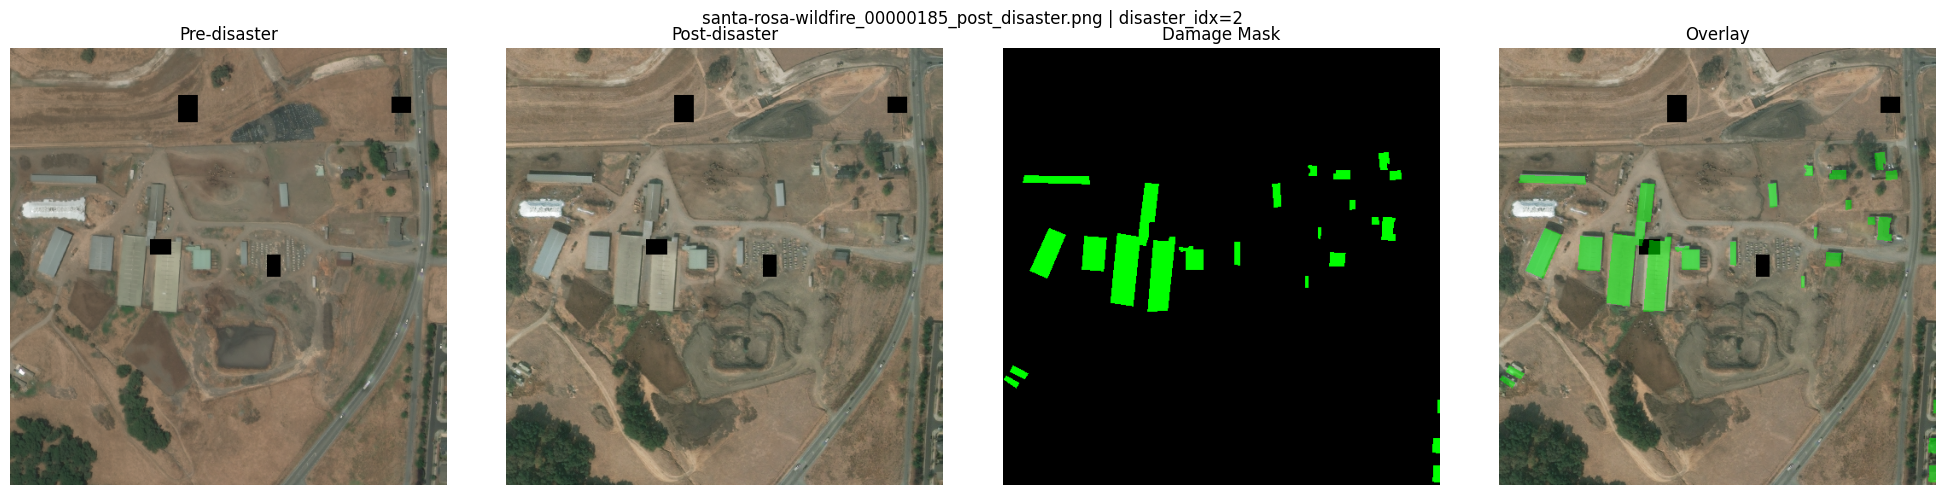


Örnek 2/4 (idx=228):


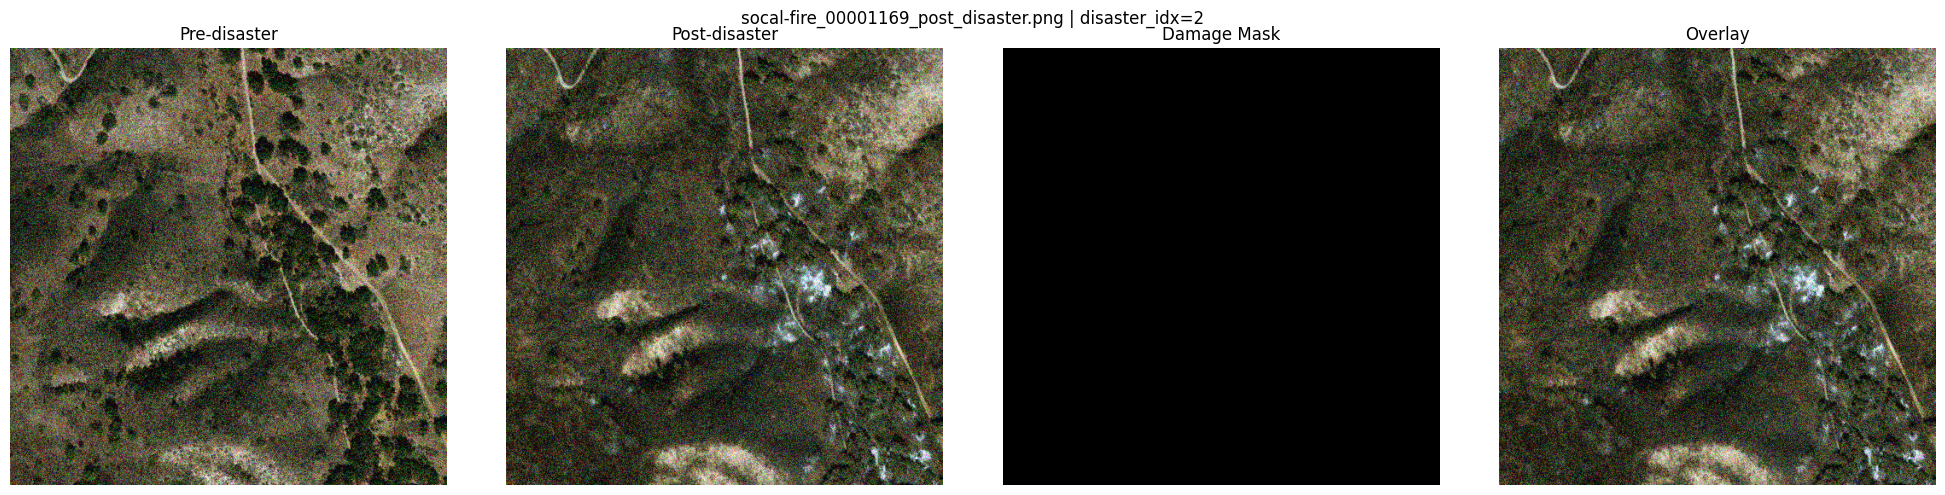


Örnek 3/4 (idx=51):


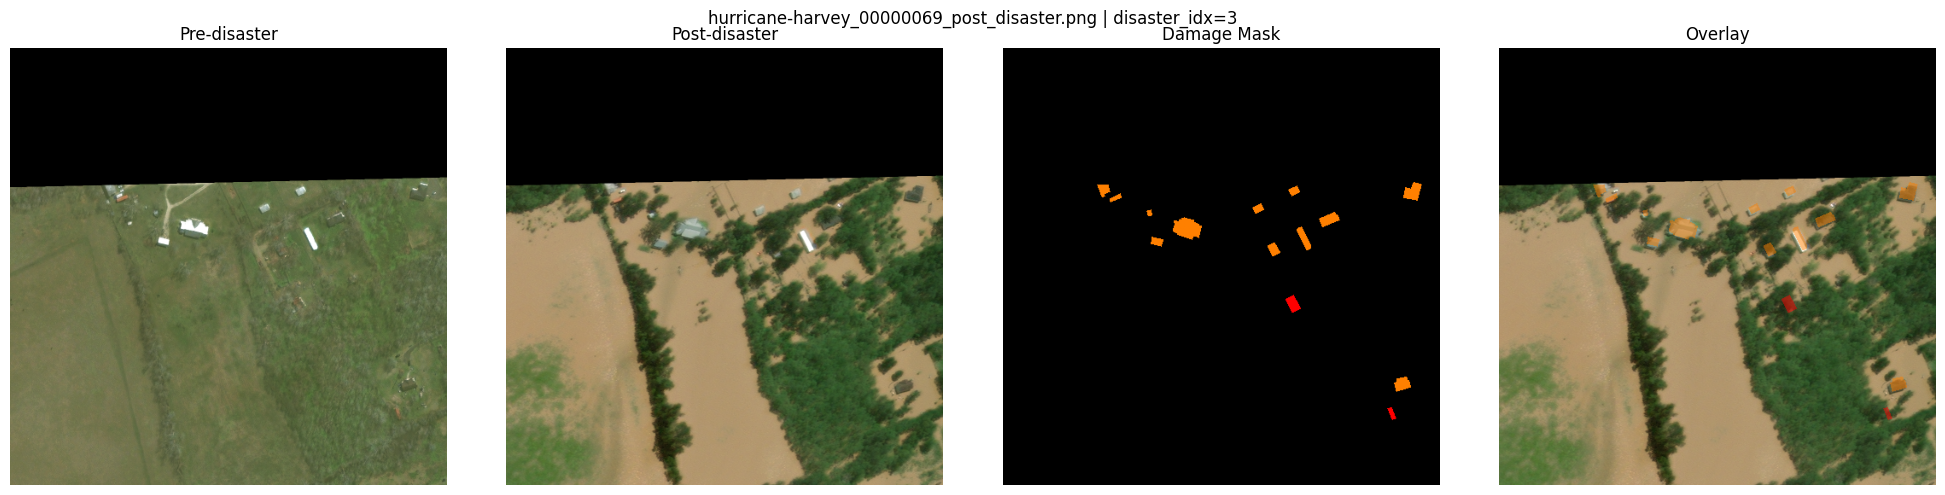


Örnek 4/4 (idx=1518):


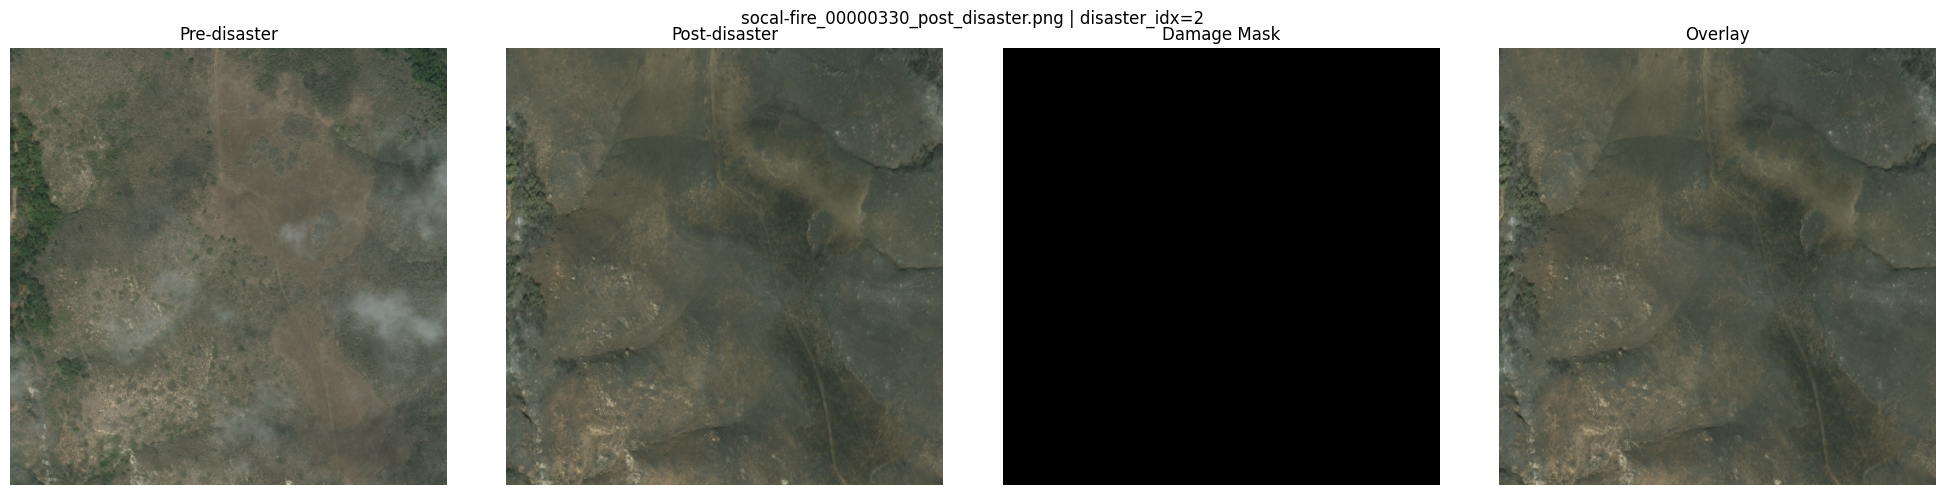

In [10]:
import sys
sys.path.insert(0, SRC_DIR)

import importlib
import dataset, augmentations, utils
importlib.reload(dataset)
importlib.reload(augmentations)
importlib.reload(utils)

from dataset import XBDDataset
from augmentations import get_train_augmentation
from utils import visualize_sample
import torch

# === Test 1: Teacher mode (6 kanal) ===
print("🧪 Test 1: Teacher mode (6 kanal pre+post)")
print("=" * 50)

train_aug = get_train_augmentation(image_size=512, mode="teacher")
train_ds = XBDDataset(
    csv_path=os.path.join(DATA_SPLITS, "train.csv"),
    mode="teacher",
    augmentation=train_aug,
)

print(f"✅ Dataset oluşturuldu: {len(train_ds)} örnek")

for i in [0, 100, 500, 1000]:
    if i >= len(train_ds):
        continue
    sample = train_ds[i]
    print(f"\n  Örnek {i}:")
    print(f"    image shape:  {tuple(sample['image'].shape)}")
    print(f"    mask shape:   {tuple(sample['mask'].shape)}")
    print(f"    mask unique:  {sorted(sample['mask'].unique().tolist())}")
    print(f"    disaster_idx: {sample['disaster_idx'].item()}")
    print(f"    filename:     {sample['filename']}")

    assert sample['image'].shape == (6, 512, 512)
    assert sample['mask'].shape == (512, 512)
    assert sample['mask'].dtype == torch.long

print("\n✅ Tüm shape kontrolleri başarılı")

# === Test 2: Student mode (3 kanal) ===
print("\n\n🧪 Test 2: Student mode (3 kanal sadece post)")
print("=" * 50)

student_aug = get_train_augmentation(image_size=512, mode="student")
student_ds = XBDDataset(
    csv_path=os.path.join(DATA_SPLITS, "train.csv"),
    mode="student",
    augmentation=student_aug,
)

sample = student_ds[0]
print(f"  image shape: {tuple(sample['image'].shape)}")
print(f"  mask shape:  {tuple(sample['mask'].shape)}")
assert sample['image'].shape == (3, 512, 512)
print("✅ Student mode çalışıyor")

# === Test 3: Görselleştirme ===
print("\n\n🎨 Test 3: 4 örnek görselleştirme")
print("=" * 50)

import random
random.seed(42)
sample_indices = random.sample(range(len(train_ds)), 4)

for i, idx in enumerate(sample_indices):
    sample = train_ds[idx]
    print(f"\nÖrnek {i+1}/4 (idx={idx}):")
    visualize_sample(sample)

## 🎉 Notebook 1 Tamamlandı!

### Ne yaptık?

✅ Drive bağlandı, GPU kontrol edildi
✅ Proje klasör yapısı kuruldu (12 alt klasör)
✅ xBD veri seti indirildi (Drive'a, bir kerelik)
✅ Maskeler üretildi (JSON → PNG, 5 sınıf)
✅ Dosya indeksi çıkarıldı (eğitim 100x daha hızlı olacak)
✅ Stratified train/val/test split (%70/%15/%15)
✅ `src/` modülleri yazıldı (`dataset.py`, `augmentations.py`, `utils.py`)
✅ Sanity check ile her şey çalıştığı doğrulandı

### Drive'da şu an ne var?

```
AFETSONAR/
├── data/
│   ├── raw/xview2/         ✅ Ham veri
│   ├── processed/masks/    ✅ N adet PNG mask
│   └── splits/             ✅ train.csv, val.csv, test.csv, file_index.csv
├── src/                    ✅ 4 Python modülü
├── checkpoints/            ⏳ (boş)
└── outputs/                ⏳ (boş)
```

### Sonraki Adım: Notebook 2 — Öğretmen Modeli Eğitimi

**`02_teacher_training.ipynb`** içinde şunları yapacağız:
- SegFormer-B5 yükle (HuggingFace'ten)
- Input projection 3→6 kanala genişlet
- 3 head ekle: Damage (4 sınıf) + Change (binary) + Disaster (5 sınıf)
- Plan v2 kayıp fonksiyonu: `0.70·Focal + 0.20·CE_change + 0.10·CE_disaster`
- 60 epoch eğit, mIoU ≥ 0.78 hedef
- Drive'a `teacher_best.pth` kaydet

Bu notebook'u çalıştırmadan önce **her hücrenin başarılı çalıştığından emin ol**. Hata olursa bana mesaj at.

---

**Calamitas AI · Teknofest 2025 · Notebook 1/8** 🚀